# Feature Engineering III

**Transform to log of volatility**

Author: Pete King

During EDA, I noticed that the historical volatility (feature) and future volatility (target) shared a log-linear relationship.  Hoping this transformation improves our models to learn the relationship between these important variables more quickly.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data_prep as dp

ETF_DATA_FILE = 'etf_transformed.csv'
TICKER = 'SPY'

In [2]:
etf_df = pd.read_csv(
    ETF_DATA_FILE,
    index_col='date',
    parse_dates=True
)
tickers_df = pd.read_csv('tickers.csv')
tickers = list(tickers_df['Tickers'])

Let's quickly recreate what we found during EDA to show the log-linear relationship.

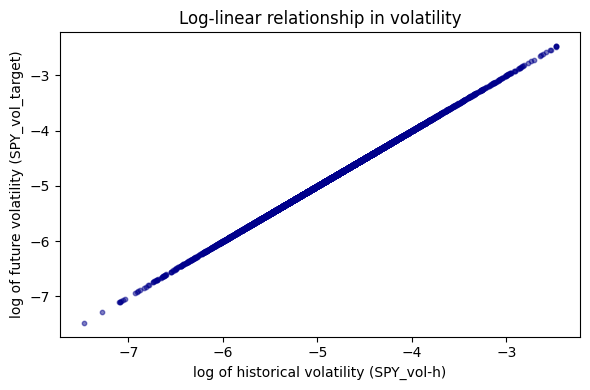

In [3]:
# Variables to be plotted
x = TICKER + '_vol-h'
y = TICKER + '_vol_target'

fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()
ax.set_title(f'Log-linear relationship in volatility')
ax.set_xlabel('log of historical volatility (' + x + ')')
ax.set_ylabel('log of future volatility (' + y + ')')
ax.scatter(
    etf_df[x].apply(np.log),
    etf_df[x].apply(np.log),
    s=10, c='#00008B', alpha=0.5
)
fig.tight_layout()

We now apply the log transformation and save the additional features and labels.

In [4]:
etf_logvol_h, etf_logvol_tgt = {}, {}
for ticker in tickers:
    etf_logvol_h[ticker + '_log_vol-h'] = etf_df[ticker + '_vol-h'].apply(np.log)
    etf_logvol_tgt[ticker + '_log_vol_target'] = etf_df[ticker + '_vol_target'].apply(np.log)

In [5]:
etf_log_df = pd.concat(
    [etf_df, pd.DataFrame(etf_logvol_h), pd.DataFrame(etf_logvol_tgt)],
    axis=1
)
etf_log_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_log_vol_target,XLE_log_vol_target,XLF_log_vol_target,XLI_log_vol_target,XLK_log_vol_target,XLP_log_vol_target,XLRE_log_vol_target,XLU_log_vol_target,XLV_log_vol_target,XLY_log_vol_target
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007087,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002117,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010515,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004176,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,-0.000109,0.003815,0.029646,0.003153,0.005257,0.012146,0.003593,0.006554,0.005557,0.003000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-26,0.000218,-0.005864,-0.038319,-0.006316,-0.008107,-0.017546,-0.007848,-0.024157,-0.018020,-0.003638,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-27,0.000327,0.000000,0.034492,-0.002537,0.000106,-0.017695,-0.002413,-0.019730,-0.017199,-0.000820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


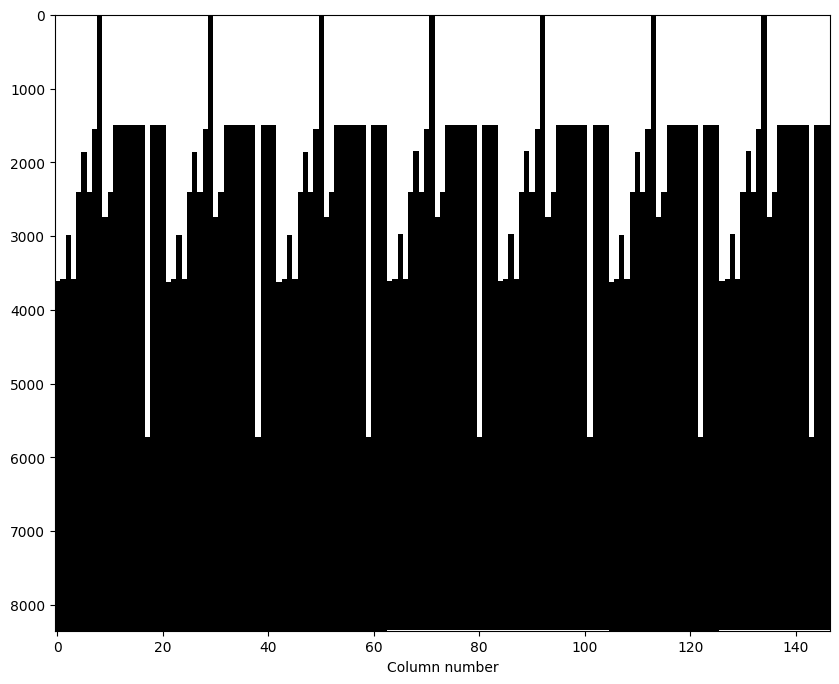

In [6]:
dp.view_nan(etf_log_df);

In [7]:
etf_log_df.to_csv('etf_transformed_log.csv', index_label='date')